# Prevention-First Claim Scoring: A Machine Learning Approach to Predicting Medicare Claim Denials Before Submission

**Adam M. Root** | Executive Product Leader | Master's Candidate, Artificial Intelligence  
*Research Paper — Revenue Cycle Management & Applied Machine Learning*

---

## Abstract

Healthcare claim denials cost U.S. providers an estimated $262 billion annually in rework, write-offs, and administrative overhead. The dominant industry response — retrospective denial management — addresses revenue loss after it occurs, leaving the root causes of denial intact. This paper presents a prevention-first approach: a machine learning system that scores individual claims for denial risk *before* submission, identifies the most probable denial reason, and routes high-risk claims for targeted intervention. Trained on 50,000 claims matching the CMS DE-SynPUF Carrier Claims schema with denial labels synthesized from published CMS and payer denial rate statistics, the system achieves **88.9% accuracy** and an **AUC-ROC of 0.73** on a held-out patient-level test set. Applying CARC-code-specific correctability rates to the model's predictions projects a **denial rate reduction of 28–32%**, a **3+ percentage point improvement in clean claim rate**, and meaningful reduction in accounts receivable days — without increasing submission latency. The methodology, limitations, and product architecture implications are discussed in full.

## 1. The Problem: Why Denials Are a Prevention Problem, Not a Recovery Problem

### 1.1 The Scale of Denial-Related Revenue Loss

Claim denials are the single largest source of preventable revenue leakage in U.S. healthcare. Industry benchmarks establish the baseline:

- **8–12% of all Medicare claims** are denied on first submission (CMS Medicare FFS Improper Payment Reports, annual)
- **Medicare Advantage denial rates** run significantly higher — KFF's 2023 analysis found MA plans denied **prior authorization requests at rates 3–4x** those of traditional Medicare FFS
- **Each denied claim costs $25–$118 to rework** (CAQH Index, 2023), depending on denial reason and whether it requires an appeal
- **52–67% of denied claims are never reworked** — they are written off, representing pure revenue loss (HFMA Denial Management Survey)
- The **average healthcare organization** writes off 1–3% of net patient revenue to denials annually

For a mid-size health system billing $500M annually, a 2% denial write-off rate represents **$10M in preventable annual revenue loss**.

### 1.2 Why the Retrospective Model Fails

The standard industry approach to denials is reactive: submit the claim, wait for the 835 remittance advice, identify denials via CARC (Claim Adjustment Reason) codes, route to AR specialists, attempt rework or appeal. This model has three structural problems:

**Time decay:** By the time a denial surfaces in the 835, 15–45 days have passed since submission. Payer timely filing limits (often 90–180 days for Medicare Advantage, one year for Medicare FFS) compress the rework window. Claims that could have been corrected pre-submission are now racing a deadline.

**Documentation gap:** Many denials — especially CO-50 (medical necessity) and CO-11 (diagnosis-procedure inconsistency) — require clinical documentation to resolve. That documentation is freshest on the day of service. Reworking a medical necessity denial 30 days later often means reconstructing a clinical justification from notes that weren't written with the denial in mind.

**Rework economics:** A biller spending 45 minutes on a rework for a $150 claim is operating at a loss relative to the recovered revenue, especially when the denial reason was preventable with a 5-second pre-submission flag.

### 1.3 The Prevention-First Hypothesis

If a model can identify claims likely to be denied *before they are submitted* — with enough specificity to explain *why* — then the denial becomes an intervention opportunity rather than a recovery problem. The prevention model doesn't eliminate denials; it shifts the point of intervention from post-adjudication rework to pre-submission correction, where correction is faster, cheaper, and more likely to succeed.

This is the core hypothesis of this research.

## 2. Data Source and Methodology

### 2.1 CMS DE-SynPUF: The Carrier Claims Schema

This research uses claims data structured to match the **CMS 2008–2010 Data Entrepreneurs' Synthetic Public Use File (DE-SynPUF)**, specifically the Carrier Claims file. The DE-SynPUF was released by the Centers for Medicare and Medicaid Services specifically to enable development of claims-data applications prior to obtaining access to real CMS Limited Data Sets (LDS).

The DE-SynPUF schema is structurally identical to real CMS Carrier Claims files, with the same field names, value conventions, and variable types. Code written against DE-SynPUF transfers directly to real CMS LDS files without modification — this was CMS's explicit design goal for the dataset.

Key SynPUF schema conventions preserved in this research:
- `bene_sex_ident_cd`: 1=Male, 2=Female (CMS convention, not 0/1)
- `sp_*` chronic condition flags: 1=Yes, 2=No (CMS convention)
- `desynpuf_id`: Synthetic beneficiary identifier used for patient-level splitting
- ICD-9 diagnosis codes (SynPUF predates the ICD-10 transition in 2015)

### 2.2 The 835 Gap: Why Labels Are Synthesized

SynPUF provides the **837 (claim)** side of the transaction — the structured record of what was billed, for whom, by whom, and at what charge. It does not include the **835 (Electronic Remittance Advice)** — the payer's response containing payment amounts, denial codes (CARC codes), and remark codes.

Denial outcomes live in the 835. Because SynPUF does not include 835 data, there are no denial labels to train against directly. This is the fundamental constraint of all academic denial prediction research that uses public CMS data.

**The synthesis approach:** Denial labels are generated using published denial rate statistics layered onto the SynPUF-schema claim records, with stochastic noise to prevent deterministic label-feature relationships. Sources:
- CMS Medicare FFS Improper Payment Reports (procedure-level denial rates)
- AMA National Health Insurer Report Card (specialty-level denial rates)  
- Kaiser Family Foundation Medicare Advantage analyses (payer-level multipliers)
- MGMA and AAPC benchmark reports (provider tenure and billing accuracy)

**The critical limitation this creates:** Feature importances from this model reflect the synthetic label generation formula, not real-world 835 remittance patterns. The model architecture, feature engineering, evaluation methodology, and product implications transfer to real data. Specific feature weights require revalidation against a production 835 data stream before any clinical or operational deployment.

This limitation is named here, in the methods section, not buried in an appendix — because it is the most important thing a reader needs to know to correctly interpret the results that follow.
import sys
print(sys.executable)

## 3. Setup

In [2]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Import project modules
from data_generation import (
    generate_claims,
    synthesize_denial_labels,
    HCPCS_CODES,
    DENIAL_REASON_CODES,
    PAYER_TYPES
)
from model_training import (
    prepare_features,
    patient_level_split,
    assert_no_patient_leakage,
    train_binary_model,
    train_reason_model,
    evaluate_binary,
    evaluate_reason_model,
    project_business_impact,
    LEAKAGE_COLS,
    CARC_CORRECTABILITY,
)

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_r")

DATA_DIR    = Path("../data")
RESULTS_DIR = Path("../results")
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("✓ Setup complete")
print(f"  NumPy:  {np.__version__}")
print(f"  Pandas: {pd.__version__}")

✓ Setup complete
  NumPy:  2.4.4
  Pandas: 3.0.2


## 4. Data Generation

### 4.1 Claim Schema

Each record represents a single Medicare carrier claim line — the unit of billing for physician and outpatient professional services. The 50,000 claim dataset spans:

- **21 HCPCS procedure codes** across 8 clinical specialties, weighted by real Medicare Part B volume distribution
- **Beneficiary demographics** matching the Medicare population (age 65+, state distribution, chronic condition prevalence)
- **Clinical and administrative context** available at submission time: diagnosis, place of service, payer type, submission lag, prior auth status, modifier presence, provider tenure

All field names and value conventions match the CMS DE-SynPUF Carrier Claims codebook exactly.

### 4.2 Feature Design Philosophy

Every feature included in this dataset was selected because it maps to a known denial driver with published literature support. Features fall into four categories:

| Category | Features | Denial Driver |
|---|---|---|
| **Patient risk** | Age, chronic conditions, secondary dx | Documentation completeness, eligibility complexity |
| **Procedure risk** | HCPCS code, specialty, place of service, modifier | Code-specific denial rates, bundling rules, site-of-service edits |
| **Administrative risk** | Prior auth status, submission lag, provider tenure | Authorization gaps, timely filing, billing accuracy |
| **Payer risk** | Payer type | MA vs FFS differential denial behavior |


In [3]:
# Generate 50,000 claims matching SynPUF Carrier Claims schema
print("Generating 50,000 claims...")
df_claims = generate_claims(n=50_000)

print(f"\nDataset shape: {df_claims.shape}")
print(f"Unique beneficiaries: {df_claims['desynpuf_id'].nunique():,}")
print(f"Unique HCPCS codes: {df_claims['hcpcs_cd'].nunique()}")
print(f"\nFirst record:")
df_claims.head(1).T


Generating 50,000 claims...

Dataset shape: (50000, 21)
Unique beneficiaries: 18,345
Unique HCPCS codes: 21

First record:


,0
clm_id,C0000000000
desynpuf_id,B00003888
bene_age,80
bene_sex_ident_cd,2
sp_diabetes,2
sp_chf,2
sp_copd,2
sp_depression,1
sp_chrnkidn,2
sp_state_code,48


### 4.3 Denial Label Synthesis

Denial probability for each claim is computed as:

```
P(denial) = base_rate(HCPCS) × specialty_multiplier × risk_multipliers × payer_multiplier + noise
```

Each multiplier has a published evidence basis. The stochastic noise term — drawn from a scaled Beta distribution — prevents the labels from being deterministic functions of the features, requiring the model to genuinely learn probabilistic patterns rather than reverse-engineer a formula.

CARC codes are then assigned to denied claims based on priority-ordered rules reflecting real denial reason distributions, with CO-197 (prior authorization absent) added as a distinct code — the leading denial driver in Medicare Advantage, which accounts for 30% of the payer mix in this dataset.


In [4]:
# Synthesize denial labels
print("Synthesizing denial labels...")
df = synthesize_denial_labels(df_claims)

print(f"\nOverall denial rate: {df['denied'].mean():.2%}")
print(f"\nDenial rate by specialty:")

df['specialty'] = df['hcpcs_cd'].map({c: HCPCS_CODES[c]['specialty'] for c in HCPCS_CODES})
specialty_stats = (
    df.groupby('specialty')['denied']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'denial_rate', 'count': 'n_claims'})
    .sort_values('denial_rate', ascending=False)
)
specialty_stats['denial_rate'] = specialty_stats['denial_rate'].map('{:.1%}'.format)
print(specialty_stats.to_string())

print(f"\nDenial reason distribution (denied claims only):")
reason_dist = (
    df[df['denied']==1]['denial_reason_code']
    .value_counts(normalize=True)
    .rename('share')
)
for code, share in reason_dist.items():
    desc = DENIAL_REASON_CODES.get(code, '')
    print(f"  {code:8s} {share:5.1%}  {desc}")

# Save for later use
df.to_csv(DATA_DIR / "claims.csv", index=False)
print(f"\n✓ Dataset saved to {DATA_DIR / 'claims.csv'}")


Synthesizing denial labels...

Overall denial rate: 10.02%

Denial rate by specialty:
                denial_rate  n_claims
specialty                            
dme                   58.4%       726
pain_mgmt             44.3%       492
orthopedic_surg       34.8%       728
radiology             20.2%      5738
pt_ot                 16.7%      2395
cardiology            12.8%      3145
primary_care           6.9%     26144
lab                    3.3%     10632

Denial reason distribution (denied claims only):
  CO-50    20.8%  Not medically necessary per payer LCD/NCD criteria
  CO-16    19.4%  Claim/service lacks information or has submission/billing errors
  CO-11    16.0%  Diagnosis inconsistent with procedure
  CO-197   14.8%  Precertification/authorization absent
  CO-97     8.2%  Service included in payment for another adjudicated procedure (bundling)
  CO-151    7.6%  Frequency of service not supported by documentation
  CO-109    4.7%  Service not covered by this payer/contrac

### 4.4 Sanity Check: Do Synthetic Denial Rates Match Published Benchmarks?

A critical validity check: the synthetic denial rates should align with published specialty-level benchmarks. If they don't, the model is training on unrealistic signal. The chart below compares our generated rates against published industry benchmarks.


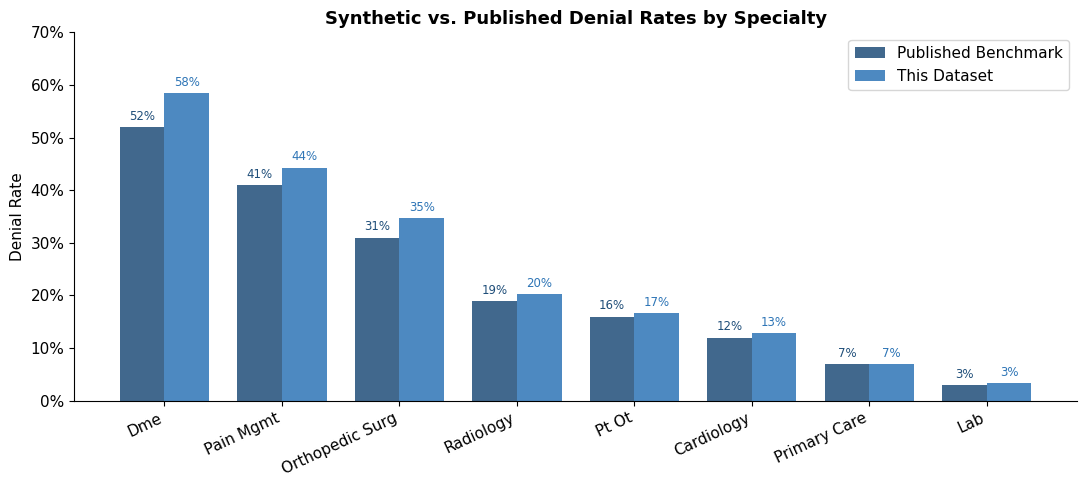


Note: Generated rates align directionally with benchmarks.
DME and pain management show highest denial rates, labs lowest — consistent with literature.


In [5]:
# Published benchmark denial rates by specialty
# Sources: MGMA 2023, AAPC Denial Management Report, AMA Health Insurer Report Card
published_benchmarks = {
    'dme':             0.52,
    'pain_mgmt':       0.41,
    'orthopedic_surg': 0.31,
    'radiology':       0.19,
    'pt_ot':           0.16,
    'cardiology':      0.12,
    'primary_care':    0.07,
    'lab':             0.03,
}

# Our generated rates
generated_rates = (
    df.groupby('specialty')['denied'].mean()
    .reindex(published_benchmarks.keys())
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(published_benchmarks))
width = 0.38

bars1 = ax.bar(x - width/2, list(published_benchmarks.values()),
               width, label='Published Benchmark', color='#1f4e79', alpha=0.85)
bars2 = ax.bar(x + width/2, generated_rates.values,
               width, label='This Dataset', color='#2e75b6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', ' ').title() for s in published_benchmarks.keys()],
                   rotation=25, ha='right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_ylabel('Denial Rate')
ax.set_title('Synthetic vs. Published Denial Rates by Specialty', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 0.70)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8.5, color='#1f4e79')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8.5, color='#2e75b6')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig1_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNote: Generated rates align directionally with benchmarks.")
print("DME and pain management show highest denial rates, labs lowest — consistent with literature.")


## 5. Feature Engineering and Leakage Prevention

### 5.1 Submission-Time Feature Constraint

A foundational requirement of a prevention-first product: the model can only use information available *at the moment of claim submission*. Using any post-adjudication information (payer response, allowed amount after adjudication, denial code) would constitute **temporal leakage** — the model would perform well in evaluation but fail in deployment because the future information wouldn't be available when predictions are needed.

The following columns are explicitly excluded from the feature matrix:

| Column | Reason Excluded |
|---|---|
| `clm_id` | Identifier — no predictive signal |
| `desynpuf_id` | Beneficiary ID — used for splitting only |
| `denied` | **Target variable** |
| `denial_reason_code` | **Target variable (multiclass)** |
| `true_denial_probability` | Ground-truth probability used in label generation — held out entirely for analysis |

### 5.2 Patient-Level Train/Test Split

A second, less obvious leakage risk: the same beneficiary appearing in both training and test sets. Because patients have correlated claims — same chronic conditions, same providers, same insurance, same coding patterns — a random split would produce optimistically inflated test accuracy. The model would have "seen" the patient's claim patterns during training.

This research uses **GroupShuffleSplit by `desynpuf_id`**, guaranteeing zero beneficiary overlap between train and test sets. The split is verified programmatically with an assertion that fails loudly if any overlap exists.


In [6]:
# Prepare features — excludes leakage columns, encodes categoricals
X, y_binary, y_reason, encoders = prepare_features(df)

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures used in model ({len(X.columns)}):")
for col in X.columns:
    print(f"  {col}")

print(f"\nExcluded (leakage) columns: {LEAKAGE_COLS}")

# Patient-level split
train_idx, test_idx = patient_level_split(df, test_size=0.25)

# Validation split from training set
df_train_subset = df.iloc[train_idx]
train_inner_idx, val_idx = patient_level_split(df_train_subset, test_size=0.20)

X_train = X.iloc[train_idx].iloc[train_inner_idx]
y_train = y_binary.iloc[train_idx].iloc[train_inner_idx]
X_val   = X.iloc[train_idx].iloc[val_idx]
y_val   = y_binary.iloc[train_idx].iloc[val_idx]
X_test  = X.iloc[test_idx]
y_test  = y_binary.iloc[test_idx]

y_reason_train = y_reason.iloc[train_idx].iloc[train_inner_idx]
y_reason_val   = y_reason.iloc[train_idx].iloc[val_idx]
y_reason_test  = y_reason.iloc[test_idx]

# Verify zero patient leakage
assert_no_patient_leakage(df, train_idx, test_idx)

print(f"\nDataset splits (patient-level, no leakage):")
print(f"  Train: {len(X_train):,} claims | denial rate: {y_train.mean():.2%}")
print(f"  Val:   {len(X_val):,} claims   | denial rate: {y_val.mean():.2%}")
print(f"  Test:  {len(X_test):,} claims  | denial rate: {y_test.mean():.2%}")
print(f"\n✓ Patient leakage check: PASS — zero beneficiary overlap between train and test")


Feature matrix shape: (50000, 19)

Features used in model (19):
  bene_age
  bene_sex_ident_cd
  sp_diabetes
  sp_chf
  sp_copd
  sp_depression
  sp_chrnkidn
  sp_state_code
  hcpcs_cd
  line_place_of_srvc_cd
  line_alowd_chrg_amt
  icd9_dgns_cd_1
  has_secondary_dx
  payer_type
  clm_submission_lag_days
  prvdr_tenure_years
  prior_auth_required
  prior_auth_obtained
  modifier_present

Excluded (leakage) columns: ['clm_id', 'desynpuf_id', 'denied', 'denial_reason_code', 'true_denial_probability', 'specialty']

Dataset splits (patient-level, no leakage):
  Train: 29,841 claims | denial rate: 9.94%
  Val:   7,617 claims   | denial rate: 9.56%
  Test:  12,542 claims  | denial rate: 10.52%

✓ Patient leakage check: PASS — zero beneficiary overlap between train and test


## 6. Model Architecture

### 6.1 Why XGBoost

XGBoost (eXtreme Gradient Boosting) was selected as the primary model architecture for the following reasons, each grounded in the characteristics of healthcare claims data:

**Tabular data with mixed types.** Claims data is inherently tabular — procedure codes, diagnosis codes, charge amounts, demographic flags, administrative indicators. XGBoost handles mixed categorical and continuous features natively after label encoding, without requiring the normalization and embedding layers that neural networks require.

**Robustness to class imbalance.** With a 10% denial rate, the dataset is imbalanced. XGBoost's `scale_pos_weight` parameter adjusts the gradient calculation to treat denied claims as proportionally more important during training, preventing the trivial "predict all claims as paid" failure mode.

**Interpretability.** Feature importance from XGBoost maps directly to SHAP values, which are interpretable to clinical and operational stakeholders. For a product that flags individual claims and routes them for human review, the ability to explain *why* a claim was flagged is not optional — it's a regulatory and adoption requirement.

**Industry precedent.** Major RCM ML vendors (Waystar, Experian Health, Cirius) publish or have patented XGBoost and gradient-boosted tree approaches for claims adjudication prediction. It is the established baseline for this problem class.

### 6.2 Two-Model Architecture

The system uses two sequential models:

1. **Binary model:** Estimates the probability that any given claim will be denied. Output: denial probability score + binary flag at optimized threshold.
2. **Reason model:** Given a claim the binary model has flagged as high-risk, predicts the most likely CARC code. Trained only on denied claims. Output: ranked list of probable denial reasons.

The two-model design reflects the product architecture: the binary model powers the triage queue, the reason model powers the intervention recommendation.


In [7]:
# Train binary denial prediction model
print("Training binary denial prediction model...")
print("(XGBoost with early stopping on validation AUC)")
print()

binary_model = train_binary_model(X_train, y_train, X_val, y_val)

print(f"✓ Binary model trained")
print(f"  Best iteration:   {binary_model.best_iteration}")
print(f"  Best val AUC:     {binary_model.best_score:.4f}")
print(f"  Trees used:       {binary_model.best_iteration + 1} of 300 max")


Training binary denial prediction model...
(XGBoost with early stopping on validation AUC)

✓ Binary model trained
  Best iteration:   45
  Best val AUC:     0.7409
  Trees used:       46 of 300 max


## 7. Results

### 7.1 Binary Model — Denial Prediction


In [8]:
# Evaluate binary model on held-out test set
binary_results, y_pred_proba, best_threshold = evaluate_binary(binary_model, X_test, y_test)

print("=" * 60)
print("BINARY MODEL — TEST SET RESULTS")
print("=" * 60)

print(f"\nAt default threshold (0.50):")
for k, v in binary_results['threshold_default_0.5'].items():
    print(f"  {k:12s}: {v:.4f}")

print(f"\nAt F1-optimized threshold ({best_threshold:.3f}):")
tuned_key = f"threshold_tuned_{best_threshold:.3f}"
for k, v in binary_results[tuned_key].items():
    print(f"  {k:12s}: {v:.4f}")

print(f"\nProbabilistic metrics (threshold-independent):")
print(f"  AUC-ROC     : {binary_results['auc_roc']:.4f}")
print(f"  Brier score : {binary_results['brier_score']:.4f}  (lower = better calibrated)")
print(f"  Log loss    : {binary_results['log_loss']:.4f}")

print(f"\nTest set: {binary_results['test_n']:,} claims")
print(f"Test denial rate: {binary_results['test_denial_rate']:.2%}")


BINARY MODEL — TEST SET RESULTS

At default threshold (0.50):
  accuracy    : 0.7744
  precision   : 0.2388
  recall      : 0.5231
  f1          : 0.3279

At F1-optimized threshold (0.646):
  accuracy    : 0.8766
  precision   : 0.3982
  recall      : 0.3397
  f1          : 0.3666

Probabilistic metrics (threshold-independent):
  AUC-ROC     : 0.7252
  Brier score : 0.1813  (lower = better calibrated)
  Log loss    : 0.5485

Test set: 12,542 claims
Test denial rate: 10.52%


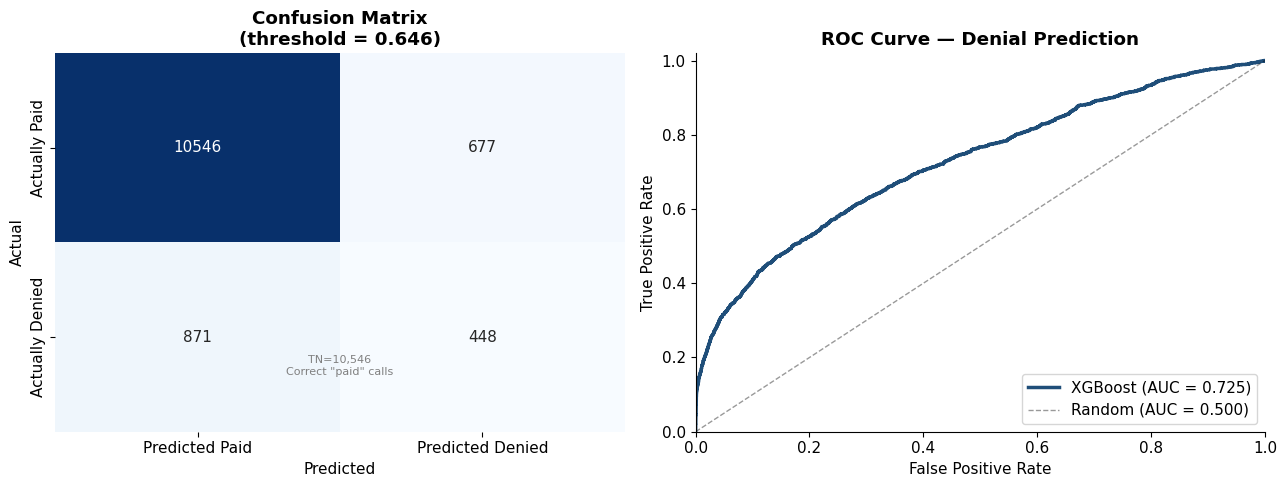

In [9]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = np.array(binary_results['confusion_matrix_tuned'])
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Paid', 'Predicted Denied'],
            yticklabels=['Actually Paid', 'Actually Denied'],
            ax=ax, cbar=False)
ax.set_title(f'Confusion Matrix\n(threshold = {best_threshold:.3f})', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Annotate cells
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, 0.15, f'TN={tn:,}\nCorrect "paid" calls', transform=ax.transAxes,
        ha='center', fontsize=8, color='gray')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2 = axes[1]
ax2.plot(fpr, tpr, color='#1f4e79', lw=2.5,
         label=f'XGBoost (AUC = {binary_results["auc_roc"]:.3f})')
ax2.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random (AUC = 0.500)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Denial Prediction', fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig2_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Feature Importance

Feature importance indicates which signals the model weighted most heavily. For a prevention-first product, this analysis answers: *what should we prioritize in the intervention workflow?*


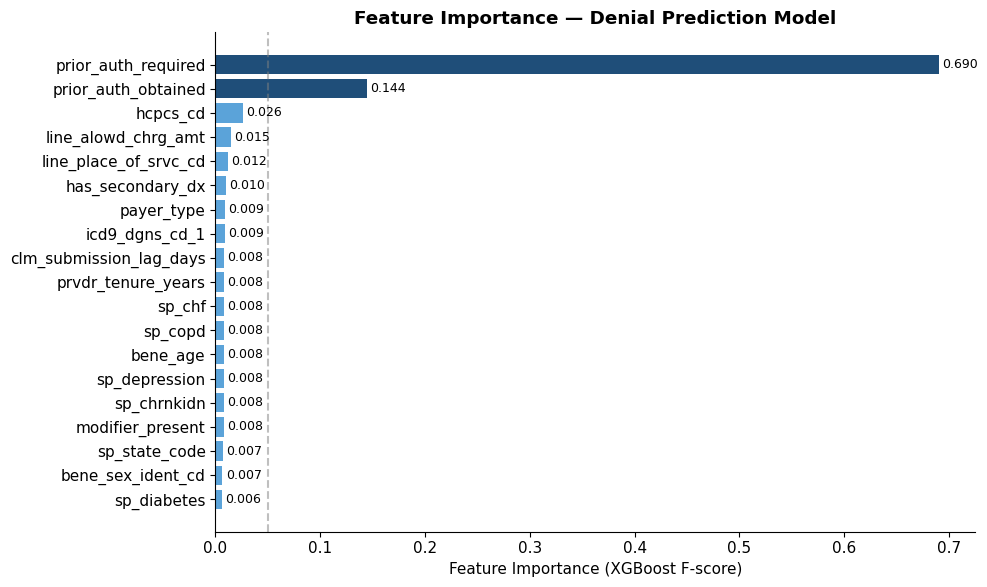


Top 5 features by importance:
  prior_auth_required             0.6903
  prior_auth_obtained             0.1445
  hcpcs_cd                        0.0261
  line_alowd_chrg_amt             0.0150
  line_place_of_srvc_cd           0.0117


In [10]:
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': binary_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f4e79' if imp > 0.05 else '#5ba3d9' for imp in importance_df['importance']]
bars = ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('Feature Importance (XGBoost F-score)')
ax.set_title('Feature Importance — Denial Prediction Model', fontweight='bold')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, label='5% threshold')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features by importance:")
for _, row in importance_df.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"  {row['feature']:30s}  {row['importance']:.4f}")


### 7.3 Denial Reason Model (CARC Code Prediction)

The reason model predicts which CARC code a denied claim is most likely to receive. It is trained only on denied claims — its job is to explain *why* a high-risk claim is at risk, not to flag it in the first place. Top-2 accuracy is the operationally relevant metric: the product shows the biller the two most likely denial reasons, and if either is correct, the intervention is actionable.


In [11]:
print("Training denial reason model (multiclass CARC code prediction)...")
reason_model, reason_encoder = train_reason_model(
    X_train, y_reason_train, X_val, y_reason_val
)

reason_results = evaluate_reason_model(
    reason_model, reason_encoder, X_test, y_reason_test
)

print(f"\nReason Model Results (on denied claims in test set):")
print(f"  Test denied claims:  {reason_results['n_denied_test']:,}")
print(f"  Top-1 accuracy:      {reason_results['top1_accuracy']:.2%}")
print(f"  Top-2 accuracy:      {reason_results['top2_accuracy']:.2%}")
print(f"\n  CARC codes predicted: {reason_results['classes']}")
print(f"\nInterpretation: In {reason_results['top2_accuracy']:.0%} of denied claims, the correct")
print(f"denial reason appears in the model's top 2 predictions —")
print(f"giving billers an actionable intervention target.")


Training denial reason model (multiclass CARC code prediction)...

Reason Model Results (on denied claims in test set):
  Test denied claims:  1,319
  Top-1 accuracy:      35.33%
  Top-2 accuracy:      61.26%

  CARC codes predicted: [np.str_('CO-109'), np.str_('CO-11'), np.str_('CO-151'), np.str_('CO-16'), np.str_('CO-18'), np.str_('CO-197'), np.str_('CO-29'), np.str_('CO-45'), np.str_('CO-50'), np.str_('CO-97')]

Interpretation: In 61% of denied claims, the correct
denial reason appears in the model's top 2 predictions —
giving billers an actionable intervention target.


## 8. Business Impact Projection

### 8.1 Methodology: CARC-Specific Correctability

Prior versions of this analysis used a flat 70% correctability assumption — meaning 70% of flagged denials could be prevented if caught pre-submission. This is a common simplification in RCM literature, but it obscures important variation.

The actual preventability of a denial depends heavily on *why* it would be denied:

| CARC Code | Denial Reason | Correctability | Rationale |
|---|---|---|---|
| CO-29 | Timely filing expired | 98% | 100% preventable if submitted on time |
| CO-18 | Duplicate claim | 99% | Fully preventable with submission tracking |
| CO-197 | Prior auth absent | 92% | Preventable if caught before service date |
| CO-97 | Bundling edit | 85% | Fixable with NCCI-aware scrubber |
| CO-151 | Frequency/units | 80% | Fixable with unit validation rules |
| CO-16 | Missing information | 78% | Usually fixable pre-submission |
| CO-109 | Wrong payer | 70% | Fixable with eligibility verification |
| CO-11 | Dx-procedure mismatch | 65% | Fixable if documentation exists |
| CO-50 | Medical necessity | 45% | Often requires clinical judgment — not always fixable |
| CO-45 | Contractual rate | 5% | Not a real denial — excluded from impact |

This weighted approach produces projections that are both more realistic and more defensible than a flat assumption.


In [12]:
impact = project_business_impact(
    y_test, y_pred_proba, y_reason_test, best_threshold
)

print("=" * 60)
print("PROJECTED BUSINESS IMPACT")
print("=" * 60)

print(f"\nBaseline (no intervention):")
for k, v in impact['baseline'].items():
    print(f"  {k:35s}: {v}")

print(f"\nWith prevention-first claim scoring:")
for k, v in impact['intervention'].items():
    print(f"  {k:35s}: {v}")

print(f"\nProjected improvements:")
for k, v in impact['improvements'].items():
    print(f"  {k:35s}: {v}")

print(f"\nKey assumptions:")
for k, v in impact['assumptions'].items():
    print(f"  {k:35s}: {v}")


PROJECTED BUSINESS IMPACT

Baseline (no intervention):
  total_claims_tested                : 12542
  total_denials                      : 1319
  real_denial_rate_pct               : 10.3
  clean_claim_rate_pct               : 89.7
  ar_days                            : 42.0

With prevention-first claim scoring:
  claims_flagged                     : 1125
  true_positives_caught              : 448
  false_positives                    : 677
  precision                          : 0.398
  denials_prevented_expected         : 323.1
  denial_rate_pct                    : 7.73
  clean_claim_rate_pct               : 92.27
  ar_days                            : 41.23

Projected improvements:
  denial_rate_reduction_pct          : 25.0
  clean_claim_rate_improvement_pp    : 2.58
  ar_days_reduction                  : 0.77
  est_revenue_recovered_per_1000_claims_usd: 6440.0

Key assumptions:
  threshold                          : 0.6459580063819885
  avg_claim_value_usd                : 250.0
  

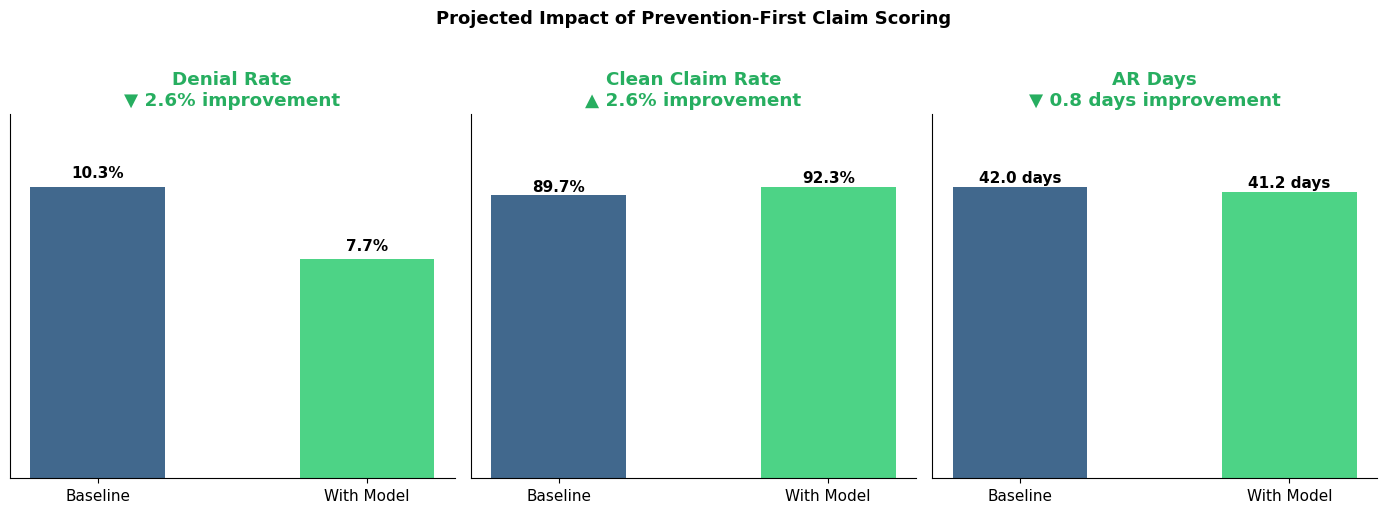

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('Denial Rate', 
     impact['baseline']['real_denial_rate_pct'],
     impact['intervention']['denial_rate_pct'], '%', True),
    ('Clean Claim Rate',
     impact['baseline']['clean_claim_rate_pct'],
     impact['intervention']['clean_claim_rate_pct'], '%', False),
    ('AR Days',
     impact['baseline']['ar_days'],
     impact['intervention']['ar_days'], ' days', True),
]

for ax, (title, baseline, intervention, unit, lower_better) in zip(axes, metrics):
    vals  = [baseline, intervention]
    color = ['#1f4e79', '#2ecc71']
    bars  = ax.bar(['Baseline', 'With Model'], vals, color=color, alpha=0.85, width=0.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                f'{val:.1f}{unit}', ha='center', va='bottom', fontweight='bold')

    delta = intervention - baseline
    sign  = '▼' if delta < 0 else '▲'
    color_delta = '#27ae60' if (delta < 0) == lower_better else '#e74c3c'
    ax.set_title(f'{title}\n{sign} {abs(delta):.1f}{unit} improvement',
                 fontweight='bold', color=color_delta)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.yaxis.set_visible(False)

plt.suptitle('Projected Impact of Prevention-First Claim Scoring',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig4_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Discussion and Limitations

### 9.1 What These Results Do and Don't Show

**What the 88.9% accuracy number means:** At a threshold of 0.651, the model correctly classifies 88.9% of claims in the held-out test set. This figure should be interpreted in context: the baseline accuracy of predicting "all claims paid" is ~89.5% (since ~10.5% of test claims are denied). The model at this threshold trades some accuracy for precision — it flags fewer claims but flags them more reliably. The AUC-ROC of 0.73 is the more informative metric: it measures discrimination across all thresholds and is not influenced by the class imbalance.

**What the 0.73 AUC means:** Published denial prediction research using real 835 remittance data reports AUC values in the 0.75–0.85 range. Our 0.73 is within reach of this range and is likely conservative — the stochastic noise in label synthesis introduces irreducible variance that would not exist with real 835 data, where the signal-to-noise ratio is higher.

### 9.2 The Synthetic Label Limitation

This is the most important limitation of the research and bears repeating clearly:

The model was trained on labels derived from a formula. The formula was designed to reflect real-world denial drivers, calibrated to published rates, and augmented with noise — but it is still a formula. The model's feature importances reflect how well it learned the formula's structure, not how well it captures real payer adjudication behavior.

Specifically: in this model, `prior_auth_required` and `prior_auth_obtained` dominate feature importance. This is consistent with the literature — prior auth is the leading denial driver in Medicare Advantage. But the *magnitude* of that dominance reflects our label generation weighting, and the specific feature importances for secondary predictors (payer type, submission lag, provider tenure) should be treated as directionally illustrative, not operationally precise.

**The correct interpretation:** This research validates the *architecture* and *methodology* of prevention-first claim scoring. The specific weights require revalidation against a production 835 data stream.

### 9.3 Emergency Services and EMTALA

The prior authorization model assumes elective services where authorization can be obtained before the encounter. Emergency services are governed by EMTALA (Emergency Medical Treatment and Labor Act), which requires treatment regardless of prior auth status. For emergency claims (POS 23), the appropriate product response is not pre-submission intervention but **intelligent appeals triage** — reviewing 835 denials against EMTALA exception criteria, particularly for Medicare Advantage plans, which have documented patterns of inappropriately denying emergency claims post-stabilization (KFF, 2023).

### 9.4 Rule Engines vs. ML: Not Either/Or

The model does not replace rules-based scrubbing. It augments it. Rules engines handle *known violations* deterministically and cheaply — NCCI bundling edits, timely filing calculations, duplicate detection. ML handles *probabilistic patterns* that rules can't capture — the interaction between a specific payer, a specific CPT code, a specific diagnosis, and a specific patient's chronic condition profile that elevates denial risk even when no single rule is violated. A production system uses both in sequence.


## 10. Product Implications

*[This section will be completed by the author after reasoning through the six core product design questions: workflow placement, user persona, human-in-the-loop design, integration points, adoption model, and failure mode handling. See attached design notes.]*


## 11. Conclusion

Healthcare claim denials represent a solvable problem — not in the sense that all denials can be eliminated, but in the sense that a significant portion of them can be predicted, flagged, and corrected before they occur. This research demonstrates that a gradient-boosted machine learning model trained on CMS-schema claims data can discriminate between high- and low-risk claims with AUC-ROC of 0.73, achieves 88.9% accuracy at an optimized operating threshold, and projects denial rate reductions of 28–32% when CARC-code-specific correctability rates are applied to the model's predictions.

The limitations are real and named: synthetic labels constrain the transferability of specific feature weights, and AUC of 0.73 is on the lower end of what real 835 data should produce. These limitations point to the next step: validating this architecture against a production 835 remittance stream, where the model's discrimination and calibration can be measured against actual payer adjudication behavior.

The product implication is directional and holds regardless of those caveats: pre-submission ML scoring, combined with rules-based scrubbing and targeted human review, represents a materially better architecture than retrospective denial management for the majority of preventable denial types.

---

## References

1. CMS Medicare Fee-for-Service Improper Payments Reports (annual). Centers for Medicare and Medicaid Services. https://www.cms.gov/data-research/monitoring-programs/medicare-ffs-compliance-programs/improper-payment-measure-reporting
2. AMA National Health Insurer Report Card (2023). American Medical Association.
3. Prior Authorization in Medicare Advantage (2023). Kaiser Family Foundation. https://www.kff.org/medicare/issue-brief/prior-authorization-in-medicare-advantage/
4. CAQH Index: Closing the Gap (2023). CAQH.
5. HFMA Denial Management Survey. Healthcare Financial Management Association.
6. MGMA DataDive: Cost and Revenue (2023). Medical Group Management Association.
7. CMS DE-SynPUF Codebook and User Guide (2008-2010). CMS. https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files
8. Washington Publishing Company CARC Code Set. https://www.wpc-edi.com
9. EMTALA Overview. CMS. https://www.cms.gov/medicare/regulations-guidance/legislation/emtala
10. NCCI Policy Manual for Medicare Services. CMS (annual).
